In [1]:
import numpy as np
import matplotlib.pyplot as plt

image_j = np.array([
    [0, 2, 2, 3, 6],
    [1, 2, 3, 3, 6],
    [2, 3, 3, 4, 7],
    [1, 2, 3, 3, 7],
    [0, 2, 4, 5, 6],
])

Compute Histogram Result: [2 2 6 7 2 1 3 2]


<function matplotlib.pyplot.show(close=None, block=None)>

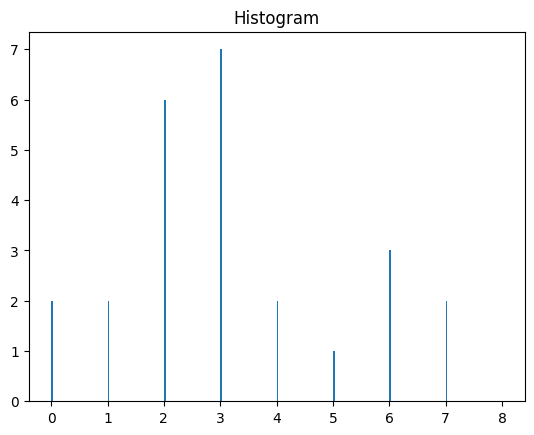

In [2]:
#Compute histogram
def histogram():
    #8: Grey range 0 -> 7
    histo = [0] * 8
    #Count intensity of each pixel
    for row in image_j:
        for pixel in row:
            histo[pixel] += 1
    return np.array(histo)

a = histogram()
print(f"Compute Histogram Result: {a}")

#Plot histogram
plt.title("Histogram")
plt.hist(image_j.ravel(), bins=256, range=[0, 8])
plt.show

Compute Normalized Histogram: [0.08 0.08 0.24 0.28 0.08 0.04 0.12 0.08]


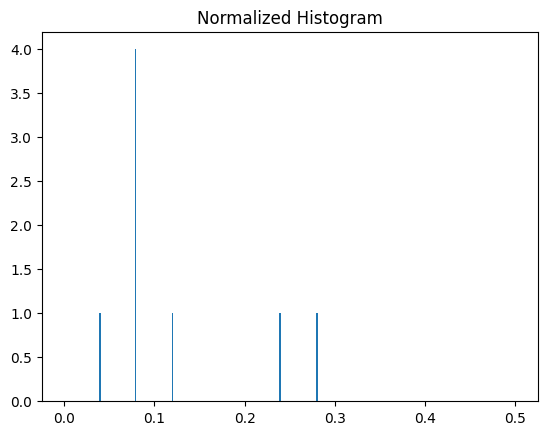

In [3]:
#Compute normalized histogram
def normalized_histogram():
    #Formula: Divide each intensity value to total number of pixels
    h = histogram()
    return h/image_j.size

b = normalized_histogram()
print(f"Compute Normalized Histogram: {b}")

#Plot normalized histogram
plt.title("Normalized Histogram")
plt.hist(b.ravel(), bins = 256, range=[0, 0.5])
plt.show()

In [4]:
#Identify the gray-level value that appears most frequently
def most_appearances_gray():
    gray_value = np.argmax(a)
    max_freq = a[gray_value]
    return gray_value, max_freq

val, freq = most_appearances_gray() 
print(f"Gray-level value: {val} appears most frequently with {freq} times")

Gray-level value: 3 appears most frequently with 7 times


In [6]:
#Threshold k = 3
def convert_to_binary(image_j):
    k = 3
    #uint8: Convert True, False to 1,0
    binary_image_b = (image_j >= 3).astype(np.uint8)
    
    return binary_image_b, k

binary_image_b, k_threshold = convert_to_binary(image_j)

print(f"Threshold k: {k_threshold}")
print(f"Image B: \n{binary_image_b}")

Threshold k: 3
Image B: 
[[0 0 0 1 1]
 [0 0 1 1 1]
 [0 1 1 1 1]
 [0 0 1 1 1]
 [0 0 1 1 1]]


In [8]:
#Count foreground & background pixels of image B
foreground_count = np.sum(binary_image_b == 1)
background_count = np.sum(binary_image_b == 0)
print(f"Foreground pixels of image B: {foreground_count}")
print(f"Background pixel of image B: {background_count}")

Foreground pixels of image B: 15
Background pixel of image B: 10


In [11]:
#Used to analyze 
total_pixels = binary_image_b.size
#Low-intensity percent
foreground_ratio = (foreground_count / total_pixels) * 100
#High-intensity percent
background_ratio = (background_count / total_pixels) * 100

print(f"High-intensity: {foreground_ratio}%; Low-intensity: {background_ratio}%")

High-intensity: 60.0%; Low-intensity: 40.0%
7


In [ ]:
#With the threshold = 3, it separate the low-intensity and high-intensity is good since the proportion of foreground and background pixels is kinda balance (60% / 40%)